This notebook explores what features of a question correlate with the difficulty rating that ChatGPT assigns to it.

## Cell 0: Load the data
Reads the CSV. Each row is one generated question, described by ~48 columns of code and text-complexity metrics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("code_counts (1).csv")

# First sanity check
print("Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Shape: (4002, 51)

First few rows:


,hpc_folder,hpc_filename,parent_folder,parent_filename,HPC_extraction_type,set_number,method,subject,model,question_number,...,in_question_chars,elsewhere_chars,note,question_embedding,answers_embedding,mc_choices_sim_matrix,mc_choices_sim_mean,mc_choices_sim_max,mc_choices_sim_pair,mc_choices_n
0,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,10,...,7,78,NaN,"[0.03737969696521759, 0.058951400220394135, -0...","[0.0632529929280281, 0.10908082127571106, -0.0...","[[1.0000001192092896, 0.3368501663208008, 0.79...",0.4648,0.7903,"[0, 2]",3
1,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,1,...,0,62,NaN,"[0.010622750967741013, 0.07696312665939331, 0....","[-0.020988594740629196, 0.08703333884477615, 0...","[[1.0000003576278687, 0.9657249450683594, 0.92...",0.9517,0.9728,"[0, 3]",4
2,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,2,...,13,39,NaN,"[0.013367009349167347, 0.05568365752696991, 0....","[0.0013841724721714854, 0.024392785504460335, ...","[[1.0, 0.9893238544464111, 0.8499612808227539,...",0.8762,0.9893,"[0, 1]",4
3,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,3,...,5,27,NaN,"[0.04825473576784134, 0.12876395881175995, -0....","[0.05114741250872612, 0.12854506075382233, -0....","[[0.9999998807907104, 0.23046284914016724], [0...",0.2305,0.2305,"[0, 1]",2
4,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,4,...,28,118,NaN,"[0.025255111977458, 0.016033248975872993, -0.0...","[0.022638650611042976, 0.054916393011808395, -...","[[1.0, 0.5360086560249329, 0.6038275957107544,...",0.6877,0.9725,"[0, 3]",4


## Cell 1: Plot styling and a fixed model order
Sets a consistent visual style for all plots and locks in the order models appear in (smaller → larger within each family). Using a fixed order across every chart makes comparisons readable.

In [3]:
# Make plots look nicer by default
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# Define a consistent model order for all plots
MODEL_ORDER = ["gpt-4o-mini", "gpt-4o", "o1-mini", "o1", "o3-mini"]

print("Setup complete.")

Setup complete.


## Cell 2: Sanity-check the experimental design
Counts rows by model, method, subject, and extraction type. We expect ~800 questions per model (5 × 800 ≈ 4,000) and balanced coverage across methods and subjects.

In [4]:
# How many of each kind?
print("=== ROWS PER MODEL ===")
print(df["model"].value_counts())

print("\n=== ROWS PER METHOD ===")
print(df["method"].value_counts())

print("\n=== ROWS PER SUBJECT ===")
print(df["subject"].value_counts())

print("\n=== EXTRACTION TYPE ===")
print(df["HPC_extraction_type"].value_counts(dropna=False))

=== ROWS PER MODEL ===
model
o1-mini        801
o3-mini        801
gpt-4o-mini    800
gpt-4o         800
o1             800
Name: count, dtype: int64

=== ROWS PER METHOD ===
method
multiple-choice      1002
drag-and-drop        1000
fill-in-the-blank    1000
true-false           1000
Name: count, dtype: int64

=== ROWS PER SUBJECT ===
subject
Loops            2002
If-Statements    2000
Name: count, dtype: int64

=== EXTRACTION TYPE ===
HPC_extraction_type
LLM       3968
Manual      34
Name: count, dtype: int64


## Cell 3: Mean of every HPC complexity metric, per model
The first real comparison. Each row is a model; each column is a complexity metric measured on the HPC files (the code shown to human participants).

In [5]:
# All the HPC complexity metrics at once
hpc_metrics = [
    "hpc_snippets", "hpc_newlines", "hpc_chars", "hpc_chars_nonws",
    "hpc_pykeywords", "hpc_pykeywords_cf", "hpc_max_nesting_depth",
    "hpc_tokens", "hpc_avg_tokens_per_code_line", "hpc_operators",
    "hpc_operators_per_token_ratio", "hpc_avg_line_length", "hpc_max_line_length"
]

# Mean of each metric per model
summary = df.groupby("model")[hpc_metrics].mean().round(2)
summary = summary.reindex(MODEL_ORDER)  # use our consistent order
summary

,hpc_snippets,hpc_newlines,hpc_chars,hpc_chars_nonws,hpc_pykeywords,hpc_pykeywords_cf,hpc_max_nesting_depth,hpc_tokens,hpc_avg_tokens_per_code_line,hpc_operators,hpc_operators_per_token_ratio,hpc_avg_line_length,hpc_max_line_length
model,,,,,,,,,,,,,
gpt-4o-mini,3.06,0.13,38.26,32.58,2.92,1.07,0.05,5.66,1.52,0.0,0.0,9.29,13.57
gpt-4o,3.57,0.26,40.60,34.26,3.12,1.10,0.12,5.79,1.35,0.0,0.0,7.97,12.23
o1-mini,3.69,0.28,49.86,41.49,3.54,1.38,0.15,7.20,1.75,0.0,0.0,10.68,15.60
o1,4.13,0.23,51.70,44.13,3.86,1.29,0.08,7.19,1.71,0.0,0.0,10.57,15.36
o3-mini,3.55,0.30,42.01,34.96,3.43,1.20,0.14,6.01,1.57,0.0,0.0,9.40,13.48


## Cell 4: Save the summary as a CSV artifact
Saving intermediate results as CSVs.

In [6]:
summary.to_csv("model_summary_means.csv")
print("Saved.")

Saved.


## Cell 5: Boxplot: token count per model
Tokens here = identifier names (variables, functions). Here, a boxplot shows the full distribution per model: the box covers the middle 50% of values, the line is the median, whiskers show the typical range, dots are outliers. Reveals patterns that means hide.

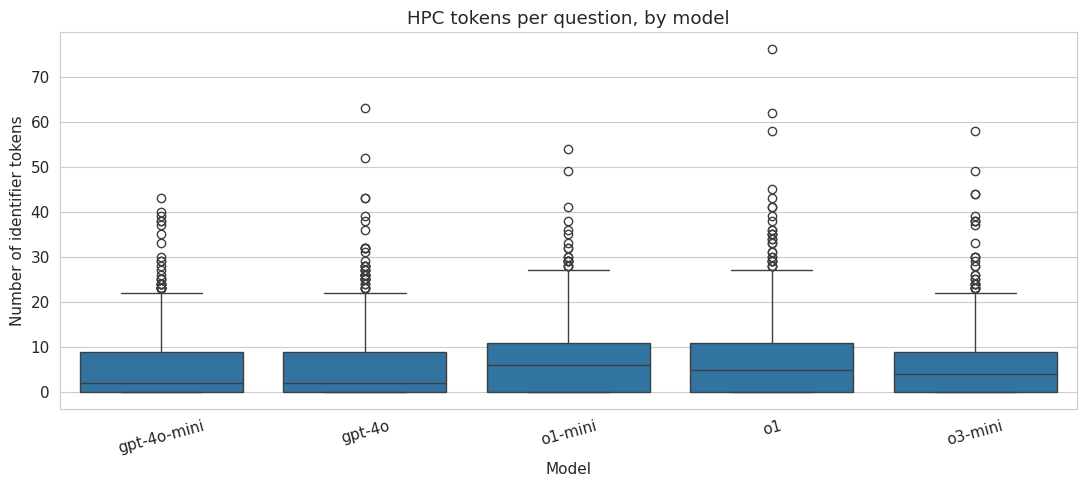

In [7]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="model", y="hpc_tokens", order=MODEL_ORDER)
plt.title("HPC tokens per question, by model")
plt.ylabel("Number of identifier tokens")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_tokens_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 6: Boxplot: control-flow keywords per model
Counts of `if`, `for`, `while`, `try`, etc.

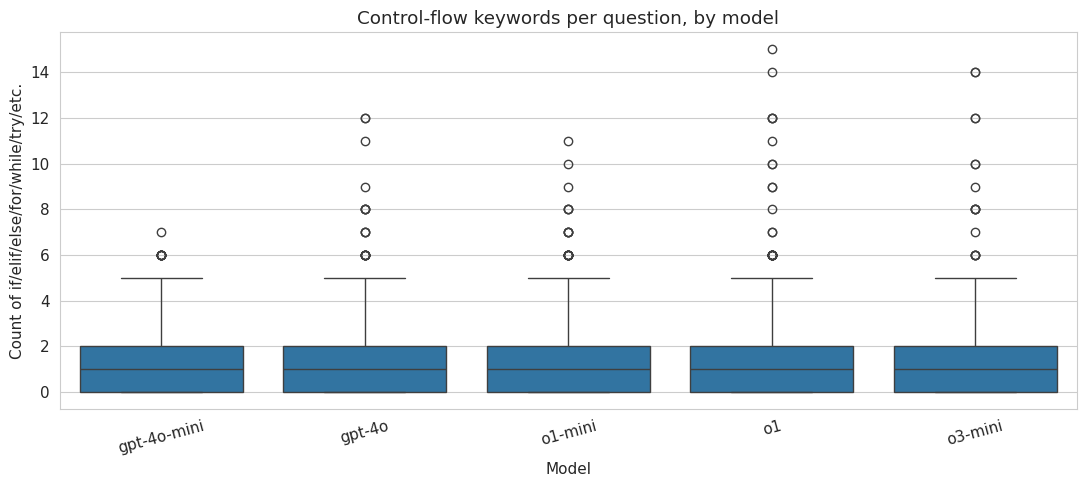

In [8]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="model", y="hpc_pykeywords_cf", order=MODEL_ORDER)
plt.title("Control-flow keywords per question, by model")
plt.ylabel("Count of if/elif/else/for/while/try/etc.")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_controlflow_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 7: Boxplot: operator density per model
Operators per token: how arithmetic-and-logic-heavy is the code per named thing. Note: this metric will turn out to be broken in our dataset (all zeros).

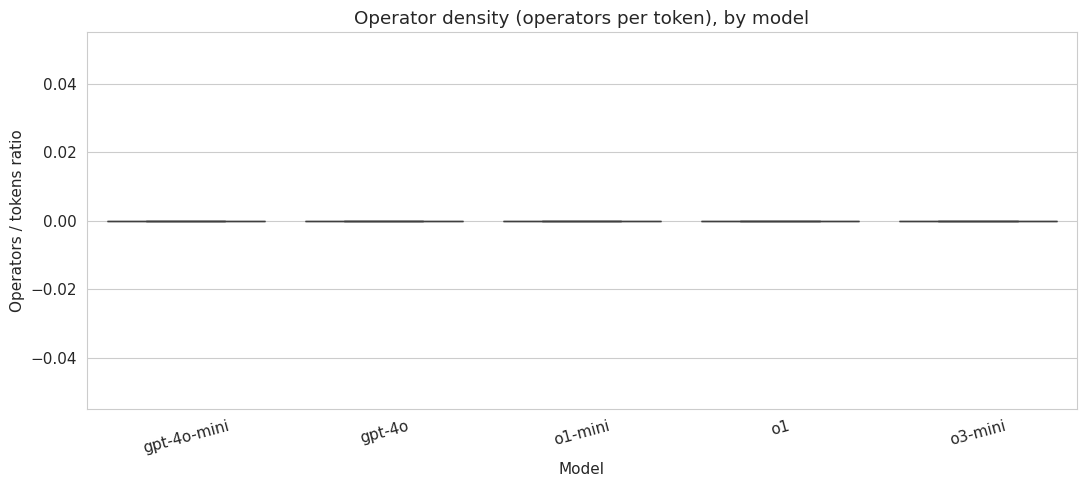

In [9]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="model", y="hpc_operators_per_token_ratio", order=MODEL_ORDER)
plt.title("Operator density (operators per token), by model")
plt.ylabel("Operators / tokens ratio")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_operator_density_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 8: Mount Google Drive
Gives Colab access to the shared drive where the JSON files live. After this runs, paths like `/content/drive/Shareddrives/...` resolve to real folders.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/content/drive/Shareddrives/LLM_dificulty_Exp/JSON_individualQs

## Cell 9: Verify the path resolves and peek at the folder
Confirms the path actually exists, counts files, and lists a sample. The filename pattern (`set_X_method_topic_model_cleaned_qN.json`) tells us how the JSONs are organized and what we'll need to parse to identify each one.

In [11]:
import os

PARENT_DIR = "/content/drive/Shareddrives/LLM_dificulty_Exp/JSON_individualQs"

print("Path exists:", os.path.exists(PARENT_DIR))
print("Number of items inside:", len(os.listdir(PARENT_DIR)))
print("First 5 items:", os.listdir(PARENT_DIR)[:5])

Path exists: True
Number of items inside: 4001
First 5 items: ['set_5_fill-in-the-blank_Loops_o1-mini_cleaned_q1.json', 'set_6_drag-and-drop_If-Statements_o1-mini_cleaned_q6.json', 'set_5_drag-and-drop_If-Statements_o1-mini_cleaned_q10.json', 'set_6_true-false_If-Statements_o1-mini_cleaned_q1.json', 'set_6_fill-in-the-blank_If-Statements_gpt-4o-mini_cleaned_q2.json']


## Cell 10: Inspect a single JSON to learn its schema
Before looping over 4,001 files, we open one and see what keys it has. We confirm `difficulty` is present as a top-level field with a numeric value 1–10. This 30-second check prevents us from running an extraction script that silently produces garbage.

In [12]:
import json

# Pick the first file
test_path = os.path.join(PARENT_DIR, "set_1_drag-and-drop_If-Statements_gpt-4o_cleaned_q1.json")

with open(test_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Keys in this JSON:", list(data.keys()))
print("\nFull contents:")
print(json.dumps(data, indent=2))

Keys in this JSON: ['difficulty', 'type', 'topic', 'question', 'code', 'options']

Full contents:
{
  "difficulty": 1,
  "type": "drag-and-drop",
  "topic": "If-Statements",
  "question": "Drag and drop to complete the basic if-statement that prints 'Hello World' if the variable 'x' is greater than 0.",
  "code": "if x > 0:\n    <blank>",
  "options": [
    "print('Hello World')",
    "x = 0",
    "else"
  ]
}


## Cell 11: List all JSON files
Uses `glob` to find every `.json` file in the parent folder.

In [13]:
import glob
import pandas as pd

all_jsons = sorted(glob.glob(os.path.join(PARENT_DIR, "*.json")))
print(f"Found {len(all_jsons)} JSON files")

Found 4001 JSON files


## Cell 12: Extract difficulty from every JSON
Loops over all 4,001 files, opens each, and pulls out `difficulty` along with a couple of other fields for cross-checking. Uses `.get()` (not `data["key"]`) so missing fields return `None` instead of crashing.

**Finding:** 121 files have no `difficulty` field at all. Zero parsing errors, just files where the field was absent.

In [14]:
records = []
errors = []

for i, path in enumerate(all_jsons):
    fname = os.path.basename(path)
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        records.append({
            "parent_filename": fname,
            "difficulty": data.get("difficulty"),
            "type_from_json": data.get("type"),
            "topic_from_json": data.get("topic"),
        })
    except Exception as e:
        errors.append((fname, str(e)))

    # Progress every 500 files
    if (i + 1) % 500 == 0:
        print(f"  Processed {i+1}/{len(all_jsons)}")

extracted = pd.DataFrame(records)
print(f"\nDone. Extracted: {len(extracted)} rows. Errors: {len(errors)}")

if errors:
    print("First few errors:", errors[:3])

print("\nDifficulty distribution:")
print(extracted["difficulty"].value_counts(dropna=False).sort_index())

extracted.head()

  Processed 500/4001
  Processed 1000/4001
  Processed 1500/4001
  Processed 2000/4001
  Processed 2500/4001
  Processed 3000/4001
  Processed 3500/4001
  Processed 4000/4001

Done. Extracted: 4001 rows. Errors: 0

Difficulty distribution:
difficulty
1.0     388
2.0     388
3.0     388
4.0     388
5.0     388
6.0     388
7.0     388
8.0     388
9.0     388
10.0    388
NaN     121
Name: count, dtype: int64


,parent_filename,difficulty,type_from_json,topic_from_json
0,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,1.0,None,None
1,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,10.0,None,None
2,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,2.0,None,None
3,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,3.0,None,None
4,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,4.0,None,None


## Cell 13: Diagnose the missing-difficulty cases

In [15]:
missing = extracted[extracted["difficulty"].isna()].copy()
print(f"Files missing difficulty: {len(missing)}")

# Pull model name from filename
import re
def extract_model(fname):
    # Filenames look like: set_X_method_topic_MODEL_cleaned_qN.json
    m = re.search(r"_(gpt-4o-mini|gpt-4o|o1-mini|o1|o3-mini)_cleaned", fname)
    return m.group(1) if m else "unknown"

missing["model"] = missing["parent_filename"].apply(extract_model)
print("\nMissing difficulty by model:")
print(missing["model"].value_counts())

Files missing difficulty: 121

Missing difficulty by model:
model
o1-mini    101
gpt-4o      20
Name: count, dtype: int64


## Cell 14: Merge difficulty into the main CSV
Left-join on `parent_filename`. After the merge, ~3,881 rows have a real difficulty value; 121 are NaN. Those NaN rows are filtered out for the correlation analysis but kept in the CSV for documentation.

In [16]:
# Merge extracted difficulty into the main CSV
df_merged = df.merge(
    extracted[["parent_filename", "difficulty"]],
    on="parent_filename",
    how="left"
)

print(f"Original CSV rows: {len(df)}")
print(f"Merged CSV rows: {len(df_merged)}")
print(f"Rows with difficulty filled in: {df_merged['difficulty'].notna().sum()}")
print(f"Rows where difficulty is missing after merge: {df_merged['difficulty'].isna().sum()}")

Original CSV rows: 4002
Merged CSV rows: 4002
Rows with difficulty filled in: 3881
Rows where difficulty is missing after merge: 121


## Cell 15: Filter to rows with a known difficulty
Drops the 121 NaN rows so correlations are computed on clean data. Ends with ~3,881 rows, evenly distributed across difficulty levels 1–10.

In [17]:
# Keep only rows where difficulty is known
df_diff = df_merged[df_merged["difficulty"].notna()].copy()
df_diff["difficulty"] = df_diff["difficulty"].astype(int)

print(f"Rows for analysis: {len(df_diff)}")
print(f"Difficulty distribution:")
print(df_diff["difficulty"].value_counts().sort_index())

Rows for analysis: 3881
Difficulty distribution:
difficulty
1     388
2     388
3     388
4     388
5     388
6     388
7     388
8     388
9     389
10    388
Name: count, dtype: int64


## Cell 16: Compute Spearman correlations across all features
For each feature, computes the rank correlation with difficulty and a p-value (probability the correlation arose by chance). Features with too few non-null values are skipped. The resulting `corr_df` is the central result table of this phase.

In [18]:
from scipy.stats import spearmanr

# Every numeric feature we want to test
features = [
    # HPC (what humans saw)
    "hpc_snippets", "hpc_newlines", "hpc_chars", "hpc_chars_nonws",
    "hpc_pykeywords", "hpc_pykeywords_cf", "hpc_max_nesting_depth",
    "hpc_tokens", "hpc_avg_tokens_per_code_line", "hpc_operators",
    "hpc_operators_per_token_ratio", "hpc_avg_line_length", "hpc_max_line_length",
    # Parent (the original ChatGPT-generated question)
    "parent_chars", "parent_snippets", "parent_newlines",
    "parent_chars_from_snippets", "parent_chars_nonws",
    "parent_pykeywords", "parent_pykeywords_cf", "parent_max_nesting_depth",
    "parent_tokens", "parent_avg_tokens_per_code_line", "parent_operators",
    "parent_operators_per_token_ratio", "parent_avg_line_length",
    "parent_max_line_length",
    # Question structure
    "parent_answerchoices_count", "parent_answerchoices_avg_len",
    "in_question", "elsewhere", "in_question_chars", "elsewhere_chars",
    # Semantic similarity (only meaningful for MC; lots of NaN for others)
    "mc_choices_sim_mean", "mc_choices_sim_max", "mc_choices_n",
]

results = []
for feat in features:
    # Drop NaN pairs for this feature (some columns have missing values)
    pair = df_diff[["difficulty", feat]].dropna()
    if len(pair) < 30:  # too few observations to trust
        results.append({"feature": feat, "rho": None, "p_value": None, "n": len(pair)})
        continue
    rho, p = spearmanr(pair["difficulty"], pair[feat])
    results.append({"feature": feat, "rho": round(rho, 3), "p_value": p, "n": len(pair)})

corr_df = pd.DataFrame(results)
# Sort by absolute st

/tmp/ipykernel_7114/1780275799.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["difficulty"], pair[feat])
/tmp/ipykernel_7114/1780275799.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["difficulty"], pair[feat])
/tmp/ipykernel_7114/1780275799.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["difficulty"], pair[feat])
/tmp/ipykernel_7114/1780275799.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["difficulty"], pair[feat])


## Cell 17: Save and preview the top 10 (unsorted)
Saves the correlation table as a CSV artifact. The "top 10" preview here is just the first 10 in original order, not sorted by strength, the next cell does the proper sort.

In [19]:
corr_df.to_csv("difficulty_correlations.csv", index=False)
print("Saved difficulty_correlations.csv")
print("\nTop 10 features by correlation strength with difficulty:")
print(corr_df.head(10).to_string(index=False))

Saved difficulty_correlations.csv

Top 10 features by correlation strength with difficulty:
                     feature    rho      p_value    n
                hpc_snippets  0.103 1.252127e-10 3881
                hpc_newlines -0.016 3.200752e-01 3881
                   hpc_chars  0.175 3.408835e-28 3881
             hpc_chars_nonws  0.176 1.997818e-28 3881
              hpc_pykeywords  0.149 1.238369e-20 3881
           hpc_pykeywords_cf  0.179 2.065778e-29 3881
       hpc_max_nesting_depth -0.016 3.053462e-01 3881
                  hpc_tokens  0.196 5.371427e-35 3881
hpc_avg_tokens_per_code_line  0.167 8.125292e-26 3881
               hpc_operators    NaN          NaN 3881


## Cell 18: Properly rank all features by correlation strength
Sorts by absolute value of rho so the strongest correlations sit at the top, regardless of sign.

**Findings:**
- **Parent-side features dominate** the top of the ranking. The strongest correlation, `parent_chars_nonws` (ρ = 0.30), beats every HPC feature. ChatGPT's difficulty rating is more closely tied to the original question text it produced than to the extracted code shown to humans.
- **All correlations are modest**: no single feature exceeds ρ = 0.30. Difficulty is multi-causal.
- **Replicates the paper's finding**: Lopez et al. reported ρ = 0.286 for question length; we get ρ = 0.300 with a slightly cleaner length measure.

In [20]:
# Sort properly and show ALL features ranked
corr_df_sorted = corr_df.copy()
corr_df_sorted["abs_rho"] = corr_df_sorted["rho"].abs()
corr_df_sorted = corr_df_sorted.sort_values("abs_rho", ascending=False, na_position="last")

print("ALL features, ranked by correlation strength with difficulty:")
print(corr_df_sorted[["feature", "rho", "p_value", "n"]].to_string(index=False))

ALL features, ranked by correlation strength with difficulty:
                         feature    rho      p_value    n
              parent_chars_nonws  0.300 2.828691e-81 3881
      parent_chars_from_snippets  0.299 7.337069e-81 3881
                   parent_tokens  0.264 6.537917e-63 3881
          parent_max_line_length  0.256 4.004717e-59 3881
                    parent_chars  0.197 4.196834e-35 3881
                      hpc_tokens  0.196 5.371427e-35 3881
            parent_pykeywords_cf  0.195 1.579733e-34 3881
             hpc_max_line_length  0.189 1.576020e-32 3881
             hpc_avg_line_length  0.188 3.156487e-32 3881
               hpc_pykeywords_cf  0.179 2.065778e-29 3881
                 hpc_chars_nonws  0.176 1.997818e-28 3881
                       hpc_chars  0.175 3.408835e-28 3881
               in_question_chars  0.175 3.468484e-28 3881
    hpc_avg_tokens_per_code_line  0.167 8.125292e-26 3881
               parent_pykeywords  0.158 4.046962e-23 3881
          

## Cell 19: Diagnose the four NaN correlations
Four operator-related columns returned NaN. The diagnostic confirms they're all zero across the entire dataset. These columns should be excluded from analysis or recomputed.

In [21]:
# Why is hpc_operators NaN?
print("hpc_operators stats:")
print(df_diff["hpc_operators"].describe())
print(f"\nUnique values: {df_diff['hpc_operators'].nunique()}")
print(f"\nValue counts:")
print(df_diff["hpc_operators"].value_counts().head())

hpc_operators stats:
count    3881.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: hpc_operators, dtype: float64

Unique values: 1

Value counts:
hpc_operators
0    3881
Name: count, dtype: int64


## Cell 20: Bar chart: all correlations at a glance
Horizontal bar chart, color-coded: parent features blue, HPC features orange, others gray. The visual proof of the "parent beats HPC" finding: the top of the chart is mostly blue.

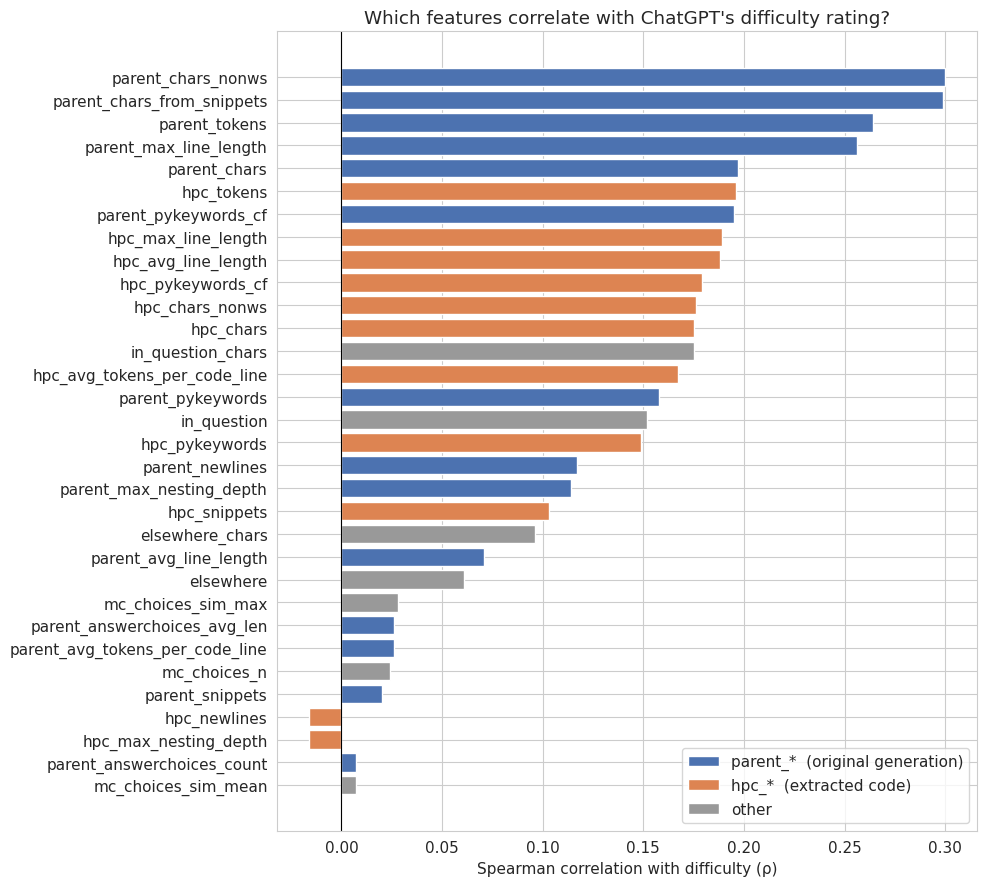

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop the dead operator columns and any rows with no rho
plot_data = corr_df_sorted.dropna(subset=["rho"]).copy()
plot_data = plot_data[~plot_data["feature"].str.contains("operator")]

# Color: parent features one color, HPC features another, others gray
def feature_color(f):
    if f.startswith("parent_"): return "#4C72B0"  # blue
    if f.startswith("hpc_"):    return "#DD8452"  # orange
    return "#999999"  # gray for the rest

colors = [feature_color(f) for f in plot_data["feature"]]

plt.figure(figsize=(10, 9))
plt.barh(plot_data["feature"], plot_data["rho"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Spearman correlation with difficulty (ρ)")
plt.title("Which features correlate with ChatGPT's difficulty rating?")
plt.gca().invert_yaxis()  # strongest at top

# Manual legend
from matplotlib.patches import Patch
legend = [Patch(facecolor="#4C72B0", label="parent_*  (original generation)"),
          Patch(facecolor="#DD8452", label="hpc_*  (extracted code)"),
          Patch(facecolor="#999999", label="other")]
plt.legend(handles=legend, loc="lower right")
plt.tight_layout()
plt.savefig("plot1_all_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 21: Scatter plot: strongest feature vs difficulty
Shows `parent_chars_nonws` (the strongest predictor) against difficulty, with a regression line. The cloud of points is wide and noisy- that's what ρ = 0.30 actually looks like. The trend is real but explains only ~9% of the variance in difficulty.

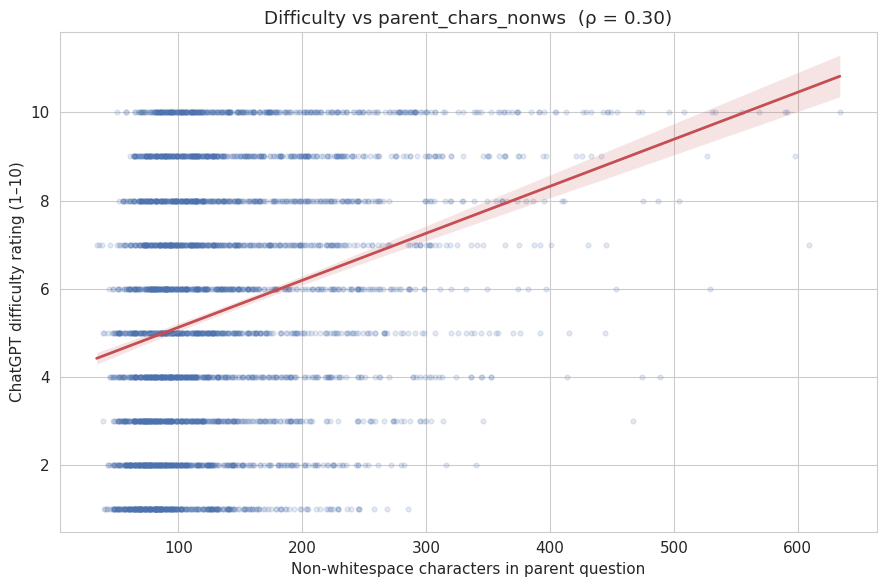

In [23]:
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df_diff,
    x="parent_chars_nonws",
    y="difficulty",
    scatter_kws={"alpha": 0.15, "s": 12, "color": "#4C72B0"},
    line_kws={"color": "#C44E52", "linewidth": 2},
)
plt.title(f"Difficulty vs parent_chars_nonws  (ρ = 0.30)")
plt.xlabel("Non-whitespace characters in parent question")
plt.ylabel("ChatGPT difficulty rating (1–10)")
plt.tight_layout()
plt.savefig("plot2_scatter_top_feature.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 22: Boxplot version of the same relationship
Same data as Cell 21, but as a boxplot. Easier to read with thousands of points: medians drift upward as difficulty increases, but the boxes overlap heavily across levels.

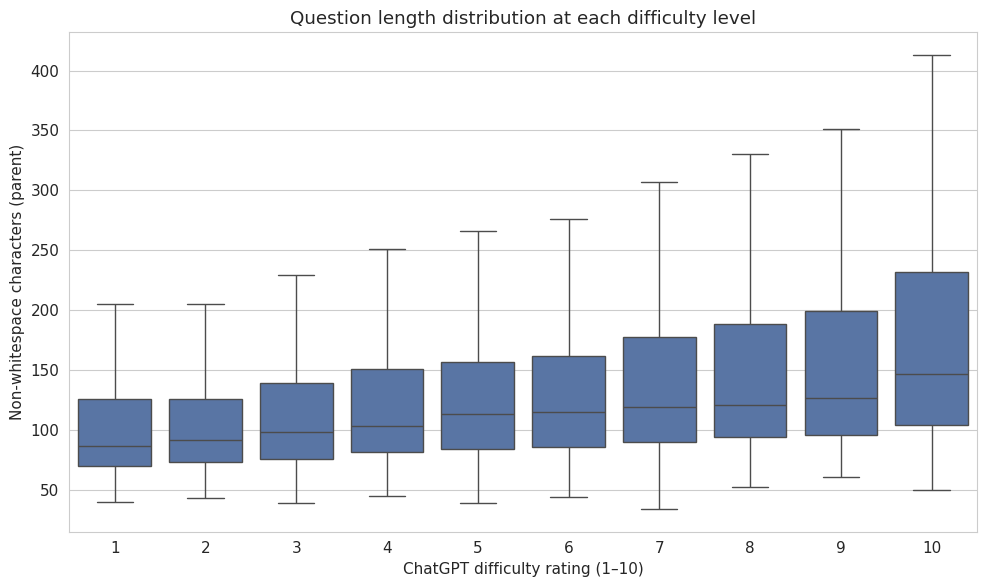

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_diff,
    x="difficulty",
    y="parent_chars_nonws",
    color="#4C72B0",
    showfliers=False,  # hide extreme outliers so boxes are readable
)
plt.title("Question length distribution at each difficulty level")
plt.xlabel("ChatGPT difficulty rating (1–10)")
plt.ylabel("Non-whitespace characters (parent)")
plt.tight_layout()
plt.savefig("plot3_boxplot_top_feature.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 23: Side-by-side comparison: parent vs HPC at the same metric
Visual proof of the parent-beats-HPC finding. Left panel (parent) shows a clearer upward trend than the right panel (HPC). When ChatGPT rates a question difficult, the original text length predicts it better than the extracted-code length does.

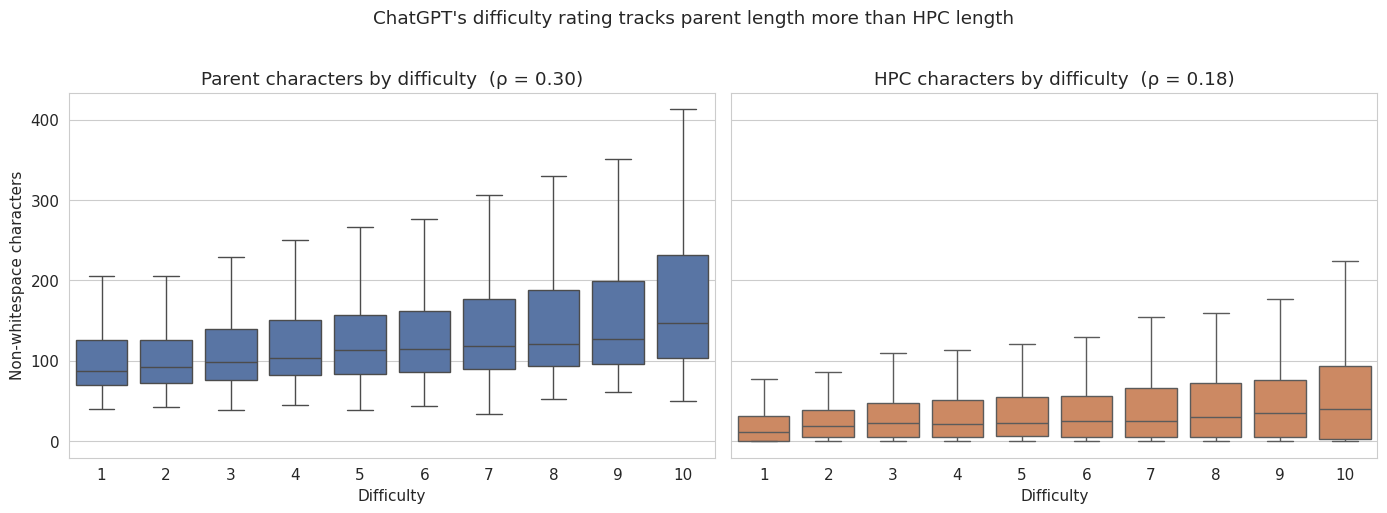

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: parent
sns.boxplot(data=df_diff, x="difficulty", y="parent_chars_nonws",
            color="#4C72B0", showfliers=False, ax=axes[0])
axes[0].set_title("Parent characters by difficulty  (ρ = 0.30)")
axes[0].set_xlabel("Difficulty")
axes[0].set_ylabel("Non-whitespace characters")

# Right: HPC
sns.boxplot(data=df_diff, x="difficulty", y="hpc_chars_nonws",
            color="#DD8452", showfliers=False, ax=axes[1])
axes[1].set_title("HPC characters by difficulty  (ρ = 0.18)")
axes[1].set_xlabel("Difficulty")
axes[1].set_ylabel("")

plt.suptitle("ChatGPT's difficulty rating tracks parent length more than HPC length", y=1.02)
plt.tight_layout()
plt.savefig("plot4_parent_vs_hpc.png", dpi=150, bbox_inches="tight")
plt.show()

So far we've pooled all 5 models. Now we ask whether each model uses the same features when assigning difficulty. Three possibilities: identical (difficulty is a property of the question), agree on direction but differ in magnitude (some models lean more on certain features), or genuinely disagree (model "personality" differences).

## Cell 24: Spearman correlations split by model
For each (feature, model) pair, computes the correlation. Result is a feature × model table: the heart of the model-comparison analysis.

In [26]:
from scipy.stats import spearmanr

# Subset of features worth comparing — top performers + a few interesting nulls
key_features = [
    "parent_chars_nonws", "parent_tokens", "parent_max_line_length",
    "parent_pykeywords_cf", "hpc_tokens", "hpc_pykeywords_cf",
    "hpc_max_nesting_depth", "parent_max_nesting_depth",
    "mc_choices_sim_max", "parent_answerchoices_avg_len",
]

models = ["gpt-4o-mini", "gpt-4o", "o1-mini", "o1", "o3-mini"]

# Build a table: rows = features, columns = models, values = Spearman rho
per_model = {}
for model in models:
    sub = df_diff[df_diff["model"] == model]
    rhos = {}
    for feat in key_features:
        pair = sub[["difficulty", feat]].dropna()
        if len(pair) < 30:
            rhos[feat] = None
            continue
        rho, _ = spearmanr(pair["difficulty"], pair[feat])
        rhos[feat] = round(rho, 3)
    per_model[model] = rhos

per_model_df = pd.DataFrame(per_model)
per_model_df = per_model_df[models]  # consistent column order

# Add a "pooled" column for reference (all models combined)
pooled = {}
for feat in key_features:
    pair = df_diff[["difficulty", feat]].dropna()
    rho, _ = spearmanr(pair["difficulty"], pair[feat])
    pooled[feat] = round(rho, 3)
per_model_df["POOLED"] = pd.Series(pooled)

per_model_df

,gpt-4o-mini,gpt-4o,o1-mini,o1,o3-mini,POOLED
parent_chars_nonws,0.269,0.338,0.313,0.278,0.365,0.300
parent_tokens,0.233,0.288,0.285,0.237,0.342,0.264
parent_max_line_length,0.235,0.282,0.285,0.258,0.299,0.256
parent_pykeywords_cf,0.133,0.246,0.186,0.171,0.256,0.195
hpc_tokens,0.143,0.173,0.222,0.205,0.252,0.196
hpc_pykeywords_cf,0.126,0.182,0.174,0.183,0.231,0.179
hpc_max_nesting_depth,-0.034,-0.051,-0.016,0.016,0.004,-0.016
parent_max_nesting_depth,0.075,0.111,0.152,0.096,0.155,0.114
mc_choices_sim_max,-0.008,0.015,0.024,0.050,0.052,0.028
parent_answerchoices_avg_len,0.013,0.028,0.026,0.045,0.018,0.026


## Cell 25: Heatmap of per-model correlations
Visualizes the table from Cell 24. Rows uniformly red across all columns = features every model relies on. Mixed-color rows = features where models disagree.

**Finding:** All models broadly agree on direction: no row goes positive for some models and negative for others. But magnitudes vary systematically. o3-mini's difficulty ratings correlate most strongly with surface features (top of the heatmap is darkest red on its column); gpt-4o-mini's correlations are consistently weakest. Two interpretations: (a) o3-mini ties difficulty more reliably to measurable code/text complexity, (b) gpt-4o-mini relies on features not captured in this dataset.

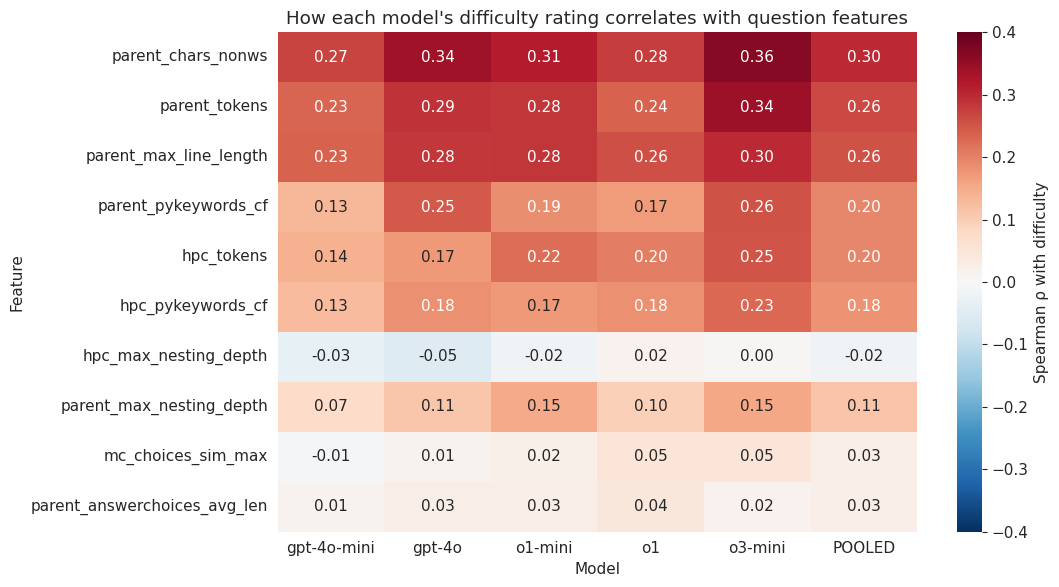

In [27]:
plt.figure(figsize=(11, 6))
sns.heatmap(
    per_model_df.astype(float),
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4,
    cbar_kws={"label": "Spearman ρ with difficulty"}
)
plt.title("How each model's difficulty rating correlates with question features")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot5_per_model_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 26: Save the per-model correlation table
Final artifact of this session: `correlations_per_model.csv`. The summary statement of where the analysis got to.

In [28]:
per_model_df.to_csv("correlations_per_model.csv")
print("Saved correlations_per_model.csv")
print("\nPer-model correlation table:")
print(per_model_df.to_string())

Saved correlations_per_model.csv

Per-model correlation table:
                              gpt-4o-mini  gpt-4o  o1-mini     o1  o3-mini  POOLED
parent_chars_nonws                  0.269   0.338    0.313  0.278    0.365   0.300
parent_tokens                       0.233   0.288    0.285  0.237    0.342   0.264
parent_max_line_length              0.235   0.282    0.285  0.258    0.299   0.256
parent_pykeywords_cf                0.133   0.246    0.186  0.171    0.256   0.195
hpc_tokens                          0.143   0.173    0.222  0.205    0.252   0.196
hpc_pykeywords_cf                   0.126   0.182    0.174  0.183    0.231   0.179
hpc_max_nesting_depth              -0.034  -0.051   -0.016  0.016    0.004  -0.016
parent_max_nesting_depth            0.075   0.111    0.152  0.096    0.155   0.114
mc_choices_sim_max                 -0.008   0.015    0.024  0.050    0.052   0.028
parent_answerchoices_avg_len        0.013   0.028    0.026  0.045    0.018   0.026


The per-model correlation table showed that o3-mini's ratings correlate more strongly with surface features than gpt-4o-mini's. But is the gap (e.g., ρ = 0.37 vs 0.27 for `parent_chars_nonws`) statistically meaningful, or could it be sampling noise from the ~780 questions per model?

**Fisher's r-to-z transformation** is the standard test. It converts a correlation `r` into a z-score using `z = 0.5 * ln((1+r)/(1-r))`, then compares two z-scores using their pooled standard error. The result is a p-value telling us how likely we'd see a gap this large by chance if the true correlations were identical.

## Define a helper function for Fisher's r-to-z comparison
A small reusable function: takes two correlations and their sample sizes, returns the z-statistic and a two-sided p-value. We'll apply it across model pairs in the next cell.

In [29]:
import numpy as np
from scipy.stats import norm

def fisher_compare(r1, n1, r2, n2):
    """
    Fisher's r-to-z test for the difference between two correlations.
    Returns (z_statistic, two_sided_p_value).
    """
    # Fisher's z transformation
    z1 = 0.5 * np.log((1 + r1) / (1 - r1))
    z2 = 0.5 * np.log((1 + r2) / (1 - r2))
    # Standard error of the difference
    se = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    # Z-statistic for the difference
    z = (z1 - z2) / se
    # Two-sided p-value
    p = 2 * (1 - norm.cdf(abs(z)))
    return z, p

# Quick sanity check using the example from the paper:
# Drag-and-Drop ρ=0.563 vs T/F ρ=0.381, both with large n
z, p = fisher_compare(0.563, 1000, 0.381, 1000)
print(f"Sanity check (paper-style example): z = {z:.2f}, p = {p:.2e}")
print("Function works." if p < 0.001 else "Check the function.")

Sanity check (paper-style example): z = 5.27, p = 1.37e-07
Function works.


## Apply Fisher's test to every pair of models, for every key feature
Loops over the 10 model pairs (5 models × 4 / 2) and the 6 strongest features. For each (feature, model_pair) combination, computes the z-statistic and p-value for the difference between their correlations.

Significant results (p < 0.05) are pairs where the models' difficulty rating *meaningfully* depends on different feature strengths — not just sampling noise. p < 0.001 = very strong evidence of a real difference.

In [30]:
from itertools import combinations
from scipy.stats import spearmanr

# Features to test — the strongest correlations from earlier
test_features = [
    "parent_chars_nonws", "parent_tokens", "parent_max_line_length",
    "parent_pykeywords_cf", "hpc_tokens", "hpc_pykeywords_cf",
]

models = ["gpt-4o-mini", "gpt-4o", "o1-mini", "o1", "o3-mini"]

# Recompute per-model correlations WITH sample sizes (we need n for Fisher's)
def model_corr(model, feat):
    sub = df_diff[df_diff["model"] == model][["difficulty", feat]].dropna()
    if len(sub) < 30:
        return None, len(sub)
    rho, _ = spearmanr(sub["difficulty"], sub[feat])
    return rho, len(sub)

# Build the comparison table
rows = []
for feat in test_features:
    for m1, m2 in combinations(models, 2):
        r1, n1 = model_corr(m1, feat)
        r2, n2 = model_corr(m2, feat)
        if r1 is None or r2 is None:
            continue
        z, p = fisher_compare(r1, n1, r2, n2)
        rows.append({
            "feature": feat,
            "model_1": m1, "rho_1": round(r1, 3), "n_1": n1,
            "model_2": m2, "rho_2": round(r2, 3), "n_2": n2,
            "z": round(z, 2),
            "p_value": p,
            "significant": p < 0.05,
        })

fisher_df = pd.DataFrame(rows)
fisher_df.to_csv("fisher_comparisons.csv", index=False)

# Show only significant results, sorted by smallest p-value
sig = fisher_df[fisher_df["significant"]].sort_values("p_value")
print(f"Total comparisons: {len(fisher_df)}")
print(f"Significant (p < 0.05): {len(sig)}")
print(f"\nSignificant model-pair differences:")
print(sig[["feature", "model_1", "rho_1", "model_2", "rho_2", "z", "p_value"]].to_string(index=False))

Total comparisons: 60
Significant (p < 0.05): 7

Significant model-pair differences:
             feature     model_1  rho_1 model_2  rho_2     z  p_value
parent_pykeywords_cf gpt-4o-mini  0.133 o3-mini  0.256 -2.55 0.010728
       parent_tokens gpt-4o-mini  0.233 o3-mini  0.342 -2.37 0.017707
parent_pykeywords_cf gpt-4o-mini  0.133  gpt-4o  0.246 -2.32 0.020512
       parent_tokens          o1  0.237 o3-mini  0.342 -2.28 0.022771
          hpc_tokens gpt-4o-mini  0.143 o3-mini  0.252 -2.25 0.024309
   hpc_pykeywords_cf gpt-4o-mini  0.126 o3-mini  0.231 -2.17 0.030079
  parent_chars_nonws gpt-4o-mini  0.269 o3-mini  0.365 -2.15 0.031624


Visualize which model pairs differ significantly, by feature
A grid of heatmaps, one per feature, showing the z-statistic for every pair of models. Cells with darker colors indicate larger (more significant) differences. Stars mark p < 0.05.

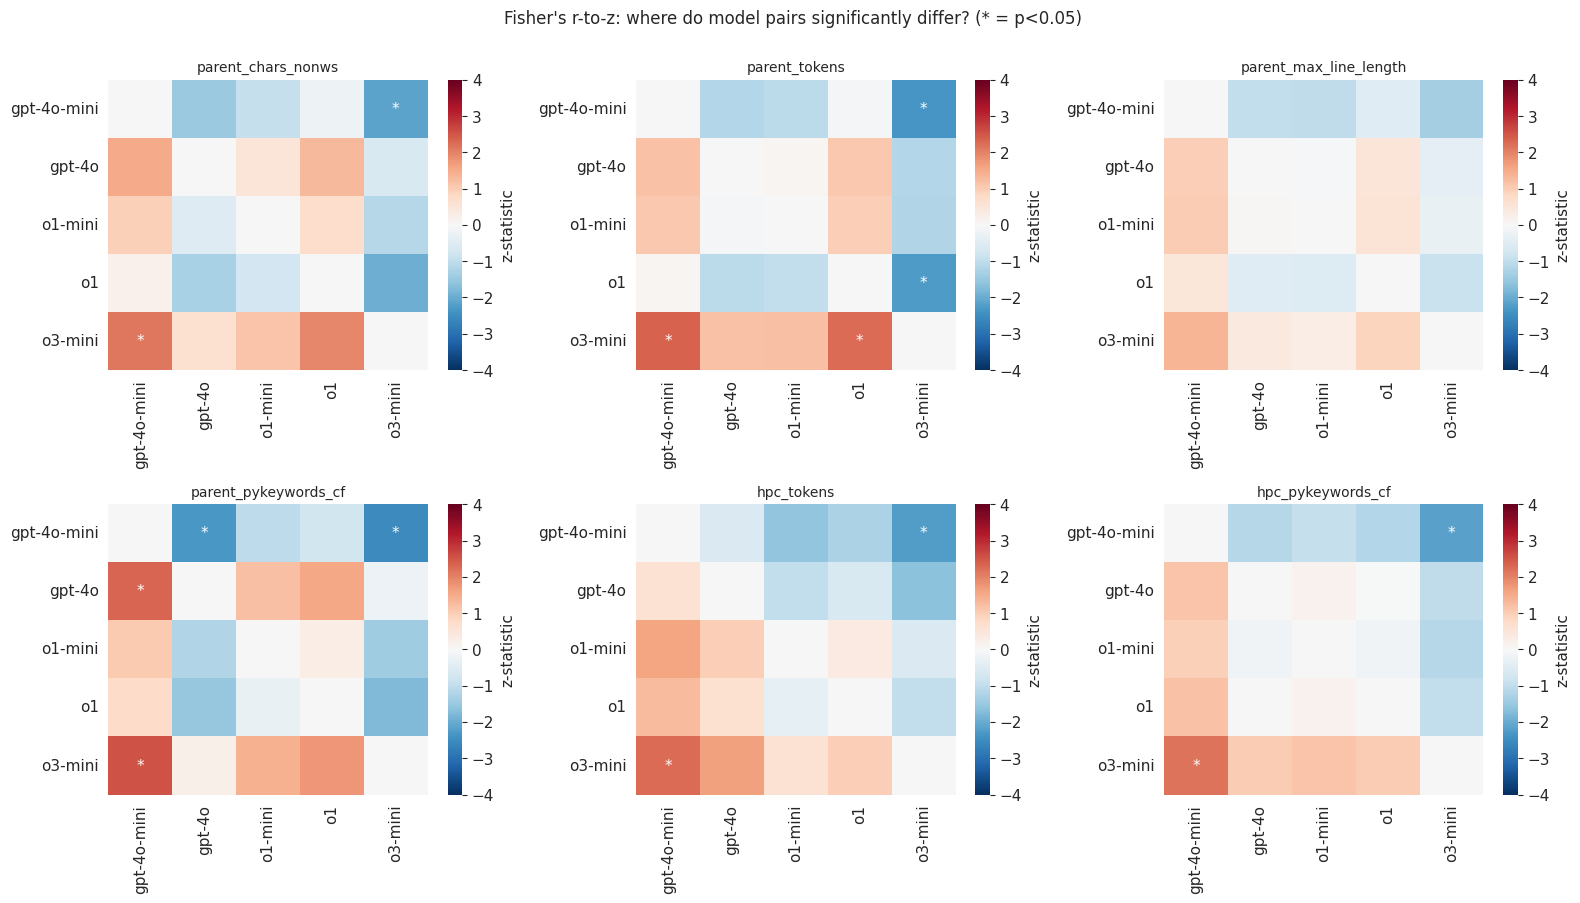

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, feat in enumerate(test_features):
    sub = fisher_df[fisher_df["feature"] == feat]
    # Build a 5x5 matrix of z-statistics; symmetric, diagonal = 0
    mat = pd.DataFrame(0.0, index=models, columns=models)
    sig_mat = pd.DataFrame("", index=models, columns=models)
    for _, row in sub.iterrows():
        mat.at[row["model_1"], row["model_2"]] = row["z"]
        mat.at[row["model_2"], row["model_1"]] = -row["z"]  # mirror
        if row["significant"]:
            sig_mat.at[row["model_1"], row["model_2"]] = "*"
            sig_mat.at[row["model_2"], row["model_1"]] = "*"

    sns.heatmap(mat, annot=sig_mat, fmt="", cmap="RdBu_r", center=0,
                vmin=-4, vmax=4, ax=axes[idx],
                cbar_kws={"label": "z-statistic"})
    axes[idx].set_title(feat, fontsize=10)
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("")

plt.suptitle("Fisher's r-to-z: where do model pairs significantly differ? (* = p<0.05)",
             y=1.00, fontsize=12)
plt.tight_layout()
plt.savefig("plot6_fisher_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlations by method
For each of the four methods (multiple-choice, drag-and-drop, fill-in-the-blank, true-false), recompute the correlation between difficulty and our key features.

In [32]:
methods = sorted(df_diff["method"].unique())
print("Methods:", methods)

# Reuse the same key features list
results_by_method = {}
for method in methods:
    sub = df_diff[df_diff["method"] == method]
    corrs = {}
    for feat in test_features:
        pair = sub[["difficulty", feat]].dropna()
        if len(pair) < 30:
            corrs[feat] = None
            continue
        rho, _ = spearmanr(pair["difficulty"], pair[feat])
        corrs[feat] = round(rho, 3)
    results_by_method[method] = corrs

method_df = pd.DataFrame(results_by_method)
# Add pooled column
method_df["POOLED"] = [round(spearmanr(df_diff[["difficulty", f]].dropna()["difficulty"],
                                        df_diff[["difficulty", f]].dropna()[f])[0], 3)
                       for f in test_features]
method_df.to_csv("correlations_by_method.csv")
print("\nCorrelation with difficulty, by method:")
print(method_df.to_string())

Methods: ['drag-and-drop', 'fill-in-the-blank', 'multiple-choice', 'true-false']

Correlation with difficulty, by method:
                        drag-and-drop  fill-in-the-blank  multiple-choice  true-false  POOLED
parent_chars_nonws              0.422              0.452            0.447       0.406   0.300
parent_tokens                   0.372              0.370            0.378       0.282   0.264
parent_max_line_length          0.292              0.377            0.033       0.393   0.256
parent_pykeywords_cf            0.231              0.218            0.327       0.129   0.195
hpc_tokens                      0.466              0.150            0.374       0.143   0.196
hpc_pykeywords_cf               0.324              0.144            0.313       0.111   0.179


## Correlations by subject (If-Statements vs Loops)

In [33]:
subjects = sorted(df_diff["subject"].unique())
print("Subjects:", subjects)

results_by_subject = {}
for subject in subjects:
    sub = df_diff[df_diff["subject"] == subject]
    corrs = {}
    for feat in test_features:
        pair = sub[["difficulty", feat]].dropna()
        if len(pair) < 30:
            corrs[feat] = None
            continue
        rho, _ = spearmanr(pair["difficulty"], pair[feat])
        corrs[feat] = round(rho, 3)
    results_by_subject[subject] = corrs

subject_df = pd.DataFrame(results_by_subject)
subject_df["POOLED"] = method_df["POOLED"]  # reuse pooled column
subject_df.to_csv("correlations_by_subject.csv")
print("\nCorrelation with difficulty, by subject:")
print(subject_df.to_string())

Subjects: ['If-Statements', 'Loops']

Correlation with difficulty, by subject:
                        If-Statements  Loops  POOLED
parent_chars_nonws              0.293  0.311   0.300
parent_tokens                   0.261  0.271   0.264
parent_max_line_length          0.239  0.273   0.256
parent_pykeywords_cf            0.229  0.196   0.195
hpc_tokens                      0.218  0.183   0.196
hpc_pykeywords_cf               0.215  0.150   0.179


##Combined heatmap — method × subject × feature
Visualizes the method and subject correlations side by side. Rows = features. Columns = each subset (4 methods + 2 subjects + pooled).

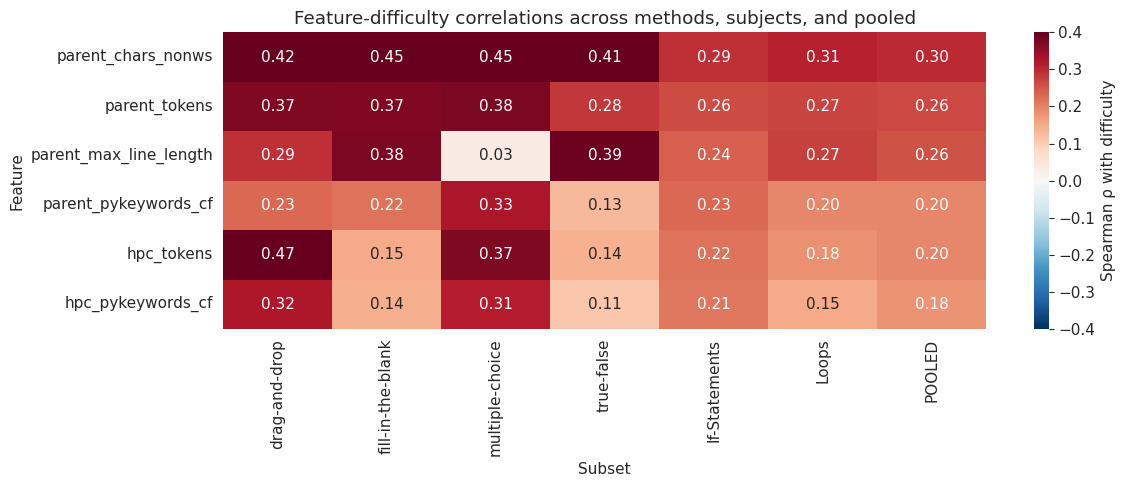

Saved correlations_method_subject_combined.csv and plot7_method_subject_heatmap.png


In [34]:
# Stack method, subject, and pooled into one big table
combined = pd.concat([method_df.drop(columns=["POOLED"]),
                      subject_df.drop(columns=["POOLED"]),
                      method_df[["POOLED"]]], axis=1)

plt.figure(figsize=(12, 5))
sns.heatmap(combined.astype(float), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4,
            cbar_kws={"label": "Spearman ρ with difficulty"})
plt.title("Feature-difficulty correlations across methods, subjects, and pooled")
plt.xlabel("Subset")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot7_method_subject_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Save the combined table
combined.to_csv("correlations_method_subject_combined.csv")
print("Saved correlations_method_subject_combined.csv and plot7_method_subject_heatmap.png")